# 미분이란 선형대수 세계관을 만들어내는 것 (뉴진수 4강)-09강 3기 04강

In [1]:
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt

x, h = sp.symbols("x h", real=True)

## 0. 내적 행렬에서 남은 의문 — $A=QDQ^{-1}$ 분해
대칭행렬 $A=\begin{pmatrix}3&1\\1&3\end{pmatrix}$ 의 고유값·고유벡터를 구하고,
정규직교 고유벡터를 열로 세운 $Q$ 가 $45^\circ$ 회전임을 확인합니다.

In [2]:
A = sp.Matrix([[3, 1], [1, 3]])
lam = sp.symbols("lambda", real=True)
charpoly = sp.factor((A - lam * sp.eye(2)).det())
print("det(A - λI) =", charpoly, "= 0")
print("eigenvalues λ =", sorted(A.eigenvals().keys()))

# orthonormal eigenvectors (columns of Q), eigenvalues on diagonal of D
P, D = A.diagonalize(normalize=True)
print("D =", D.tolist())
print("Q =", sp.nsimplify(P).tolist())
print("Q is rotation?  QᵀQ =", (P.T @ P).tolist(), "  det Q =", P.det())
print("reconstruct  Q D Q⁻¹ =", sp.simplify(P @ D @ P.inv()).tolist(), " == A")
print("rotation angle of Q =", (sp.deg(sp.atan2(P[1, 0], P[0, 0]))), "deg")

det(A - λI) = (lambda - 4)*(lambda - 2) = 0
eigenvalues λ = [2, 4]
D = [[2, 0], [0, 4]]
Q = [[-sqrt(2)/2, sqrt(2)/2], [sqrt(2)/2, sqrt(2)/2]]
Q is rotation?  QᵀQ = [[1, 0], [0, 1]]   det Q = -1
reconstruct  Q D Q⁻¹ = [[3, 1], [1, 3]]  == A
rotation angle of Q = 135 deg


## 1. 변환으로 본 타원 vs 내적으로 잰 길이
같은 그림을 두 언어로 읽습니다.
**(변환)** 단위원을 $A$ 로 보내면 장축·단축이 고유값 $\lambda=4,2$ 인 타원.
**(내적)** $A$ 로 길이를 재면 $\langle v,v\rangle_A=v^\top A v=1$ 인 단위공의 반지름은 $1/\sqrt{\lambda}$ 라
반축이 $1/\sqrt2,\ 1/2$ — 여기서 루트가 붙습니다.

In [3]:
An = np.array([[3.0, 1.0], [1.0, 3.0]])
evals, evecs = np.linalg.eigh(An)            # ascending: [2, 4]
print("eigenvalues          :", np.round(evals, 4))
print("transform image semi-axes (= λ)        :", np.round(np.sort(evals)[::-1], 4))
print("A-inner unit-ball semi-axes (= 1/√λ)   :", np.round(1 / np.sqrt(np.sort(evals)[::-1]), 4))

eigenvalues          : [2. 4.]
transform image semi-axes (= λ)        : [4. 2.]
A-inner unit-ball semi-axes (= 1/√λ)   : [0.5    0.7071]


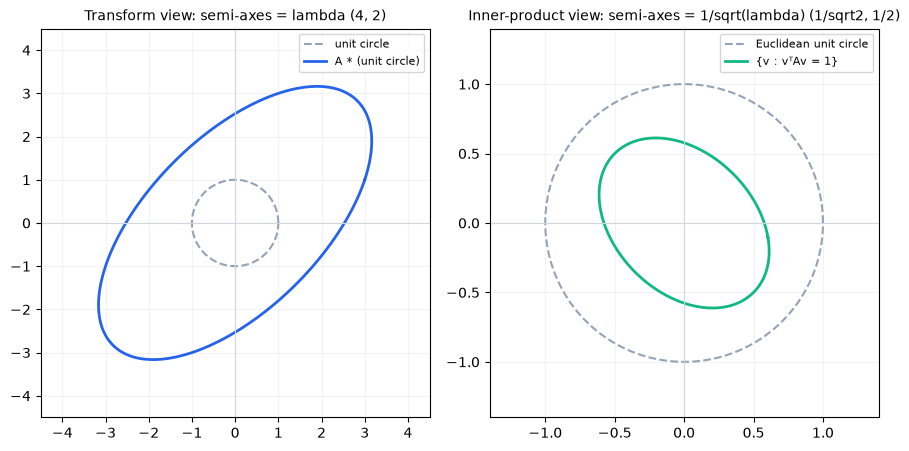

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(9, 4.4))
t = np.linspace(0, 2 * np.pi, 300)
circle = np.vstack([np.cos(t), np.sin(t)])

# (left) A as a linear transform: image of the unit circle is an ellipse with semi-axes = eigenvalues
img = An @ circle
ax = axes[0]
ax.plot(circle[0], circle[1], "--", color="#94a3b8", lw=1.5, label="unit circle")
ax.plot(img[0], img[1], color="#2563eb", lw=2, label="A * (unit circle)")
ax.set_title("Transform view: semi-axes = lambda (4, 2)", fontsize=10)
ax.set_xlim(-4.5, 4.5); ax.set_ylim(-4.5, 4.5); ax.set_aspect("equal")
ax.axhline(0, color="#d0d7de", lw=.8); ax.axvline(0, color="#d0d7de", lw=.8)
ax.grid(alpha=.15); ax.legend(fontsize=8)

# (right) A as an inner product: {v : vᵀAv = 1} has semi-axes 1/sqrt(lambda)
ax = axes[1]
inv_sqrt = evecs @ np.diag(1 / np.sqrt(evals)) @ evecs.T
ball = inv_sqrt @ circle
ax.plot(circle[0], circle[1], "--", color="#94a3b8", lw=1.5, label="Euclidean unit circle")
ax.plot(ball[0], ball[1], color="#10b981", lw=2, label="{v : vᵀAv = 1}")
ax.set_title("Inner-product view: semi-axes = 1/sqrt(lambda) (1/sqrt2, 1/2)", fontsize=10)
ax.set_xlim(-1.4, 1.4); ax.set_ylim(-1.4, 1.4); ax.set_aspect("equal")
ax.axhline(0, color="#d0d7de", lw=.8); ax.axvline(0, color="#d0d7de", lw=.8)
ax.grid(alpha=.15); ax.legend(fontsize=8)
fig.tight_layout()
plt.show()

## 3. 거꾸로 — 직교 두 벡터에서 내적 행렬을 만들면 왜 대칭인가
$A=QDQ^{-1}$ 에 전치를 취하면 $A=A^\top$ 이 되려면 $Q^{-1}=Q^\top$,
즉 $Q$ 가 직교행렬(정규직교 열)이어야 합니다. 또 일차종속이면 $Q^{-1}$ 이 없어 분해가 안 됩니다.

In [5]:
# orthonormal Q -> A = Q D Qᵀ is symmetric
q1 = sp.Matrix([1, 1]) / sp.sqrt(2)
q2 = sp.Matrix([-1, 1]) / sp.sqrt(2)
Q = q1.row_join(q2)
Dd = sp.diag(4, 2)
A_built = sp.simplify(Q @ Dd @ Q.T)
print("QᵀQ =", sp.simplify(Q.T @ Q).tolist(), " (orthonormal -> Q⁻¹ = Qᵀ)")
print("A = Q D Qᵀ =", A_built.tolist(), "  symmetric?", A_built == A_built.T)

# linearly dependent columns -> no inverse, no decomposition
bad = sp.Matrix([[1, 2], [2, 4]])
print("[[1,2],[2,4]] det =", bad.det(), " -> invertible?", bad.det() != 0)

QᵀQ = [[1, 0], [0, 1]]  (orthonormal -> Q⁻¹ = Qᵀ)
A = Q D Qᵀ = [[3, 1], [1, 3]]   symmetric? True
[[1,2],[2,4]] det = 0  -> invertible? False


## 8. 일변수 미분의 정의 — 할선 기울기의 극한
할선 기울기 $\dfrac{f(x+h)-f(x)}{h}$ 의 $h\to0$ 극한이 미분계수 $f'(x)$.
$f(x)=x^2$ 로 직접 확인하고, 한 점에서 할선이 접선으로 수렴하는 그림을 그립니다.

In [6]:
f = x**2
secant = (f.subs(x, x + h) - f) / h
print("secant slope  (f(x+h)-f(x))/h =", sp.expand(secant))
print("limit h->0                    =", sp.limit(secant, h, 0))
print("sympy diff f'(x)              =", sp.diff(f, x))

secant slope  (f(x+h)-f(x))/h = h + 2*x
limit h->0                    = 2*x
sympy diff f'(x)              = 2*x


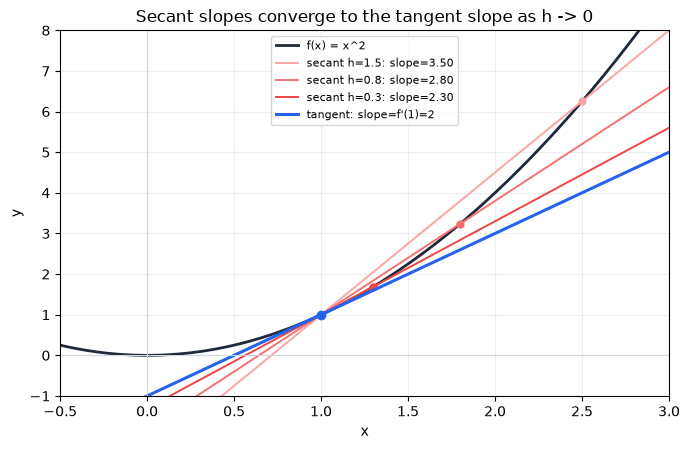

In [7]:
fx = sp.lambdify(x, f, "numpy")
x0 = 1.0
fp = float(sp.diff(f, x).subs(x, x0))      # f'(1) = 2
xs = np.linspace(-0.5, 3.0, 400)

fig, ax = plt.subplots(figsize=(7, 4.6))
ax.plot(xs, fx(xs), color="#1e293b", lw=2, label="f(x) = x^2")
for hh, col in [(1.5, "#fca5a5"), (0.8, "#f87171"), (0.3, "#ef4444")]:
    slope = (fx(x0 + hh) - fx(x0)) / hh
    ax.plot(xs, fx(x0) + slope * (xs - x0), color=col, lw=1.4,
            label=f"secant h={hh}: slope={slope:.2f}")
    ax.plot([x0 + hh], [fx(x0 + hh)], "o", color=col, ms=5)
ax.plot(xs, fx(x0) + fp * (xs - x0), color="#2563eb", lw=2.2,
        label=f"tangent: slope=f'(1)={fp:.0f}")
ax.plot([x0], [fx(x0)], "o", color="#2563eb", ms=6)
ax.set_title("Secant slopes converge to the tangent slope as h -> 0")
ax.set_xlabel("x"); ax.set_ylabel("y")
ax.set_xlim(-0.5, 3.0); ax.set_ylim(-1, 8)
ax.axhline(0, color="#d0d7de", lw=.8); ax.axvline(0, color="#d0d7de", lw=.8)
ax.grid(alpha=.2); ax.legend(fontsize=8)
fig.tight_layout()
plt.show()

## 9. 연속성 — 극한값과 함수값이 어긋나는 점
$x=1$ 에서 곡선은 $\lim_{h\to0}f(1+h)=2$ 로 다가가지만 함수값은 $f(1)=1$ 로 찍혀 있어
극한값($2$)과 함수값($1$)이 어긋나므로 불연속. 그래서 그 점의 기울기를 하나로 정할 수 없습니다.

In [8]:
# piecewise: g(x) = x+1 for x != 1, with the point at x=1 pinned to 1 (a hole at (1,2))
g = sp.Piecewise((x + 1, sp.Ne(x, 1)), (1, True))
left = sp.limit(x + 1, x, 1, dir="-")
right = sp.limit(x + 1, x, 1, dir="+")
print("lim_{h->0} f(1+h) =", left, "(left) =", right, "(right)")
print("f(1)              =", g.subs(x, 1))
print("limit == value ?  ", left == g.subs(x, 1), " -> discontinuous at x=1")

lim_{h->0} f(1+h) = 2 (left) = 2 (right)
f(1)              = 1
limit == value ?   False  -> discontinuous at x=1


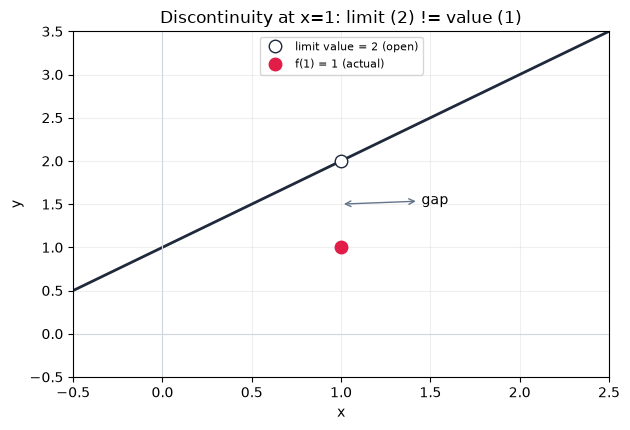

In [9]:
fig, ax = plt.subplots(figsize=(6.4, 4.4))
xl = np.linspace(-0.5, 1.0, 200)[:-1]
xr = np.linspace(1.0, 2.5, 200)[1:]
ax.plot(xl, xl + 1, color="#1e293b", lw=2)
ax.plot(xr, xr + 1, color="#1e293b", lw=2)
ax.plot([1], [2], "o", mfc="white", mec="#1e293b", ms=9, label="limit value = 2 (open)")
ax.plot([1], [1], "o", color="#e11d48", ms=9, label="f(1) = 1 (actual)")
ax.annotate("gap", xy=(1, 1.5), xytext=(1.45, 1.5), fontsize=10,
            arrowprops=dict(arrowstyle="<->", color="#64748b"))
ax.set_title("Discontinuity at x=1: limit (2) != value (1)")
ax.set_xlabel("x"); ax.set_ylabel("y")
ax.set_xlim(-0.5, 2.5); ax.set_ylim(-0.5, 3.5)
ax.axhline(0, color="#d0d7de", lw=.8); ax.axvline(0, color="#d0d7de", lw=.8)
ax.grid(alpha=.2); ax.legend(fontsize=8)
fig.tight_layout()
plt.show()

## 10. 미분가능 ⇒ 연속, 그러나 역은 거짓 — $|x|$ 의 첨점
미분계수가 존재하면 $h\to0$ 일 때 분자 $f(x+h)-f(x)\to0$ 이라 연속이 따라옵니다.
그러나 $y=|x|$ 는 $0$ 에서 연속이지만 좌·우 기울기가 $-1,\ +1$ 로 달라 미분 불가.

In [10]:
absf = sp.Abs(x)
dl = sp.limit((absf.subs(x, 0 + h) - absf.subs(x, 0)) / h, h, 0, dir="-")
dr = sp.limit((absf.subs(x, 0 + h) - absf.subs(x, 0)) / h, h, 0, dir="+")
print("|x| at 0:  left slope =", dl, "  right slope =", dr,
      " -> equal?", dl == dr, "(not differentiable)")
print("|x| continuous at 0 ?  lim =", sp.limit(absf, x, 0), "= f(0) =", absf.subs(x, 0))

|x| at 0:  left slope = -1   right slope = 1  -> equal? False (not differentiable)
|x| continuous at 0 ?  lim = 0 = f(0) = 0


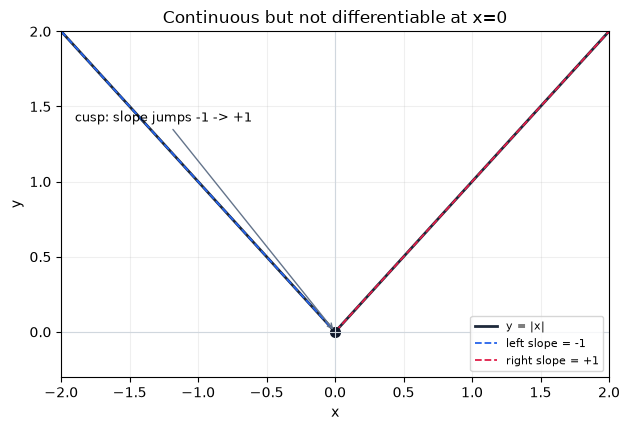

In [11]:
xs = np.linspace(-2, 2, 400)
fig, ax = plt.subplots(figsize=(6.4, 4.4))
ax.plot(xs, np.abs(xs), color="#1e293b", lw=2, label="y = |x|")
ax.plot(xs[xs <= 0], -xs[xs <= 0], "--", color="#2563eb", lw=1.3, label="left slope = -1")
ax.plot(xs[xs >= 0],  xs[xs >= 0], "--", color="#e11d48", lw=1.3, label="right slope = +1")
ax.plot([0], [0], "o", color="#0f172a", ms=7)
ax.annotate("cusp: slope jumps -1 -> +1", xy=(0, 0), xytext=(-1.9, 1.4), fontsize=9,
            arrowprops=dict(arrowstyle="->", color="#64748b"))
ax.set_title("Continuous but not differentiable at x=0")
ax.set_xlabel("x"); ax.set_ylabel("y")
ax.set_xlim(-2, 2); ax.set_ylim(-0.3, 2)
ax.axhline(0, color="#d0d7de", lw=.8); ax.axvline(0, color="#d0d7de", lw=.8)
ax.grid(alpha=.2); ax.legend(fontsize=8)
fig.tight_layout()
plt.show()